# Vehicle Damage Classification for Insurance Claim Verification

**Author:** Greatness Okeremeta  
**Dataset:** [Vehicle Damage Insurance Verification (Kaggle)](https://www.kaggle.com/datasets/sudhanshu2198/ripik-hackfest)  

## Overview

Insurance claim processing is expensive when done manually. An automated model that can classify vehicle damage type from a photo, at the point of claim submission, cuts assessment time and flags potentially fraudulent claims early.

This project builds and systematically improves a CNN to classify vehicle damage images into six categories:

| Label | Description |
|---|---|
| `crack` | Surface crack |
| `scratch` | Paint scratch |
| `dent` | Body dent |
| `tire flat` | Flat tyre |
| `glass shatter` | Shattered glass |
| `lamp broken` | Broken lamp |

Four model configurations are trained and compared, progressively introducing regularisation and hyperparameter changes to study their effect on generalisation.

## Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Tensorflow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D,
    BatchNormalization, Flatten, Dense, Dropout)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Display settings
sns_style = {'figure.dpi': 120}
plt.rcParams.update(sns_style)

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)

print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.21.0


## Data Loading & Preprocessing

The dataset consists of:
- `train.csv`: image filenames and integer labels for the training set  
- `test.csv`: image filenames for the test set  
- A folder of training images (JPEG)

In [2]:
# Configuration
IMAGE_DIR  = '/Users/greatnessokeremeta/PROJECTS/vehicle-damage-insurance-claim-verification/train images'
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32

# Damage category mapping
DAMAGE_LABELS = {
    1: 'crack',
    2: 'scratch',
    3: 'tire flat',
    4: 'dent',
    5: 'glass shatter',
    6: 'lamp broken'}

NUM_CLASSES = len(DAMAGE_LABELS)

# Load csv files
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

# Map integer labels to string names
train_df['label'] = train_df['label'].map(DAMAGE_LABELS)

print(f'Total training samples : {len(train_df)}')
print(f'Label distribution:\n{train_df["label"].value_counts()}')
train_df.head()

Total training samples : 7200
Label distribution:
label
scratch          2349
dent             2079
glass shatter    1185
lamp broken       882
tire flat         534
crack             171
Name: count, dtype: int64


,image_id,filename,label
0,1,1.jpg,scratch
1,2,2.jpg,dent
2,3,3.jpg,scratch
3,4,4.jpg,tire flat
4,5,5.jpg,glass shatter


In [3]:
# Split the training data into training and validation sets with an 80/20 split
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train_df['label']
)

print(f'Training samples  : {len(train_data)}')
print(f'Validation samples: {len(val_data)}')

Training samples  : 5760
Validation samples: 1440


## Data Augmentation

Augmentation applies random geometric and photometric transformations to training images, artificially expanding the effective dataset and reducing overfitting. Validation images are only rescaled (not augmented) to ensure unbiased evaluation.

In [6]:
def make_generators(train_data, val_data, batch_size=BATCH_SIZE):
    """ A function to create training and validation image generators.
        Training images are augmented; validation images are only rescaled.
    """
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255, # Normalizes pixels 
        rotation_range=20, # Randomly rotate images up to 20 degrees 
        width_shift_range=0.1, # Randomly shift images horizontally up to 10% of the width 
        height_shift_range=0.1, # Randomly shift images vertically up to 10% of the width 
        horizontal_flip=True, # Randomly flip images horizontally 
        vertical_flip=False, # Randomly flip images vertically 
        shear_range=0.1, # crops part of the image
        zoom_range=0.1, # zooms the image by 10%,
        brightness_range=[0.8, 1.2] # Adjust brightness between 80% and 120%
    )
    val_datagen = ImageDataGenerator(rescale=1.0 / 255) # Normalizes pixels

    common_kwargs = dict(
        directory=IMAGE_DIR,
        x_col='filename',
        y_col='label',
        target_size=IMG_SIZE,
        class_mode='categorical',
        shuffle=False,
    )

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_data, batch_size=batch_size,
        shuffle=True, seed=RANDOM_STATE, **{k: v for k, v in common_kwargs.items() if k != 'shuffle'})
    
    val_gen = val_datagen.flow_from_dataframe(
        dataframe=val_data, batch_size=batch_size, **common_kwargs)
    
    return train_gen, val_gen


train_gen, val_gen = make_generators(train_data, val_data)
CLASS_LABELS = list(train_gen.class_indices.keys())
print('Classes:', CLASS_LABELS)

Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.
Classes: ['crack', 'dent', 'glass shatter', 'lamp broken', 'scratch', 'tire flat']


## Sample Image Visualisation

A quick check that displays one sample from each damage class to confirm the data pipeline is working correctly.

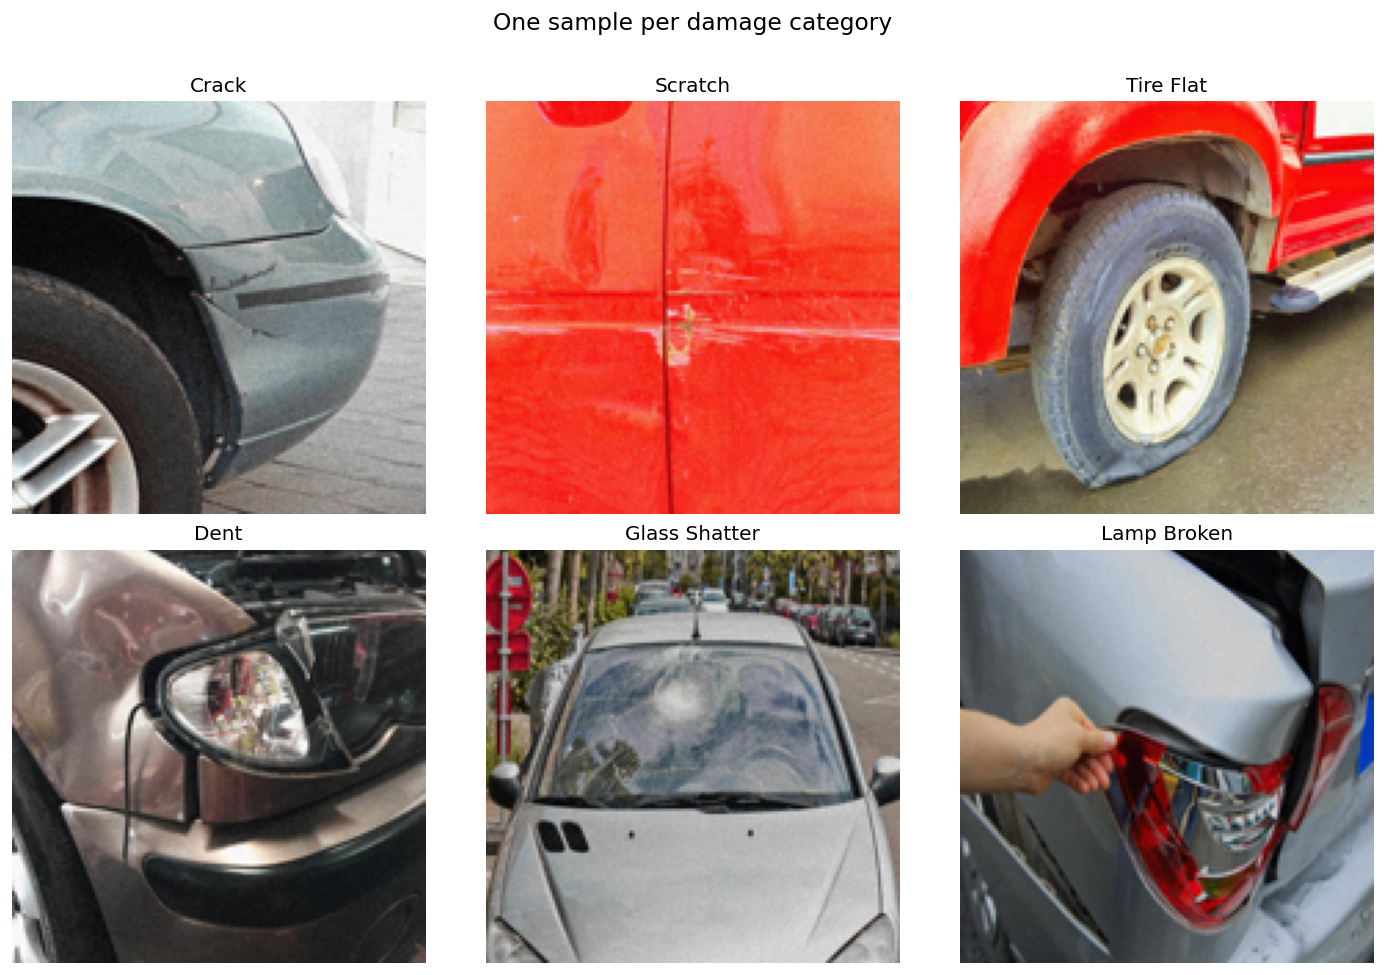

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for idx, (label_name, ax) in enumerate(zip(DAMAGE_LABELS.values(), axes)):
    sample = train_data[train_data['label'] == label_name].iloc[0]
    img_path = os.path.join(IMAGE_DIR, sample['filename'])
    img = Image.open(img_path).resize(IMG_SIZE)
    ax.imshow(img)
    ax.set_title(label_name.title(), fontsize=12)
    ax.axis('off')

plt.suptitle('One sample per damage category', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('one_sample_per_cat.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 5. Model Experiments

All four models share the same base CNN architecture:

```
Input (150×150×3)
  └─ Conv2D(32, 3×3, ReLU) → MaxPool(2×2)
  └─ Conv2D(64, 3×3, ReLU) → MaxPool(2×2)
  └─ Conv2D(128, 3×3, ReLU) → MaxPool(2×2)
  └─ Flatten → Dense(64, ReLU) → Dropout → Dense(6, Softmax)
```

- A 2-dimensional Convolution layer (`Conv2D`) with 32 filters, a kernel size of 3x3, and the `ReLU` activation function. The input shape matches the shape of the input images, i.e. (`width_npix`, `height_npix`, 3), where `width_npix` and `height_npix` are the width and height, respectively, of each image in pixels, and 3 is the three RGB channels.  
- A 2-dimensional Max Pooling layer (`MaxPooling2D`) with a pool size of 2x2.  
- A second 2-dimensional Convolution layer with 64 filters, a kernel size of 3x3, and the `ReLU` activation function.  
- A 2-dimensional Max Pooling layer (`MaxPooling2D`) with a pool size of 2x2.  
- A third 2-dimensional Convolution layer with 128 filters, a kernel size of 3x3, and the `ReLU` activation function.  
- A 2-dimensional Max Pooling layer (`MaxPooling2D`) with a pool size of 2x2.  
- A `Flatten layer`, which will flatten the outputs of the final convolution and pooling layers into 1 dimension, ready for the fully connected part
of the network.  
- A `Dense` layer with 64 neurons and the `ReLU` activation function. Apply a dropout rate of 50% to this layer.  
- A final `Dense` layer with 6 neurons and the `Softmax` activation function. The outputs from this layer will give the probability distribution of the 6 possible class labels

**Helper functions**

In [9]:
def plot_training_curves(history, model_name):
    """A function to plot the side-by-side loss and accuracy curves for a fitted Keras history object."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history.history['loss'], label='Train', linewidth=1.5)
    axes[0].plot(history.history['val_loss'], label='Validation', linewidth=1.5)
    axes[0].set_title(f'{model_name}_Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Categorical Cross-Entropy')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train', linewidth=1.5)
    axes[1].plot(history.history['val_accuracy'], label='Validation', linewidth=1.5)
    axes[1].set_title(f'{model_name}_Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [10]:
def evaluate_model(model, generator, model_name, class_labels):
    """A function to print the classification report and display confusion matrix."""
    y_pred  = np.argmax(model.predict(generator, verbose=0), axis=-1)
    y_true  = generator.classes

    print(f'\n {model_name}: Classification Report')
    report = classification_report(
        y_true, y_pred,
        target_names=class_labels,
        zero_division=0)
    
    print(report)

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=class_labels,
        ax=ax, colorbar=False, cmap='Blues')
    
    ax.set_title(f'{model_name}_Confusion Matrix')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return report

In [11]:
def build_base_cnn(dropout_rate=0.5, batch_norm=False):
    """A function to construct the shared CNN architecture.

    Arguments:
        dropout_rate: Fraction of units to drop in the Dense head.
        batch_norm: If True, add BatchNormalization after each pooling layer.
    """
    model = Sequential(name='vehicle_damage_cnn')
    model.add(Input(shape=(*IMG_SIZE, 3)))

    for filters in [32, 64, 128]:
        model.add(Conv2D(filters, (3, 3), activation='relu', padding='same'))
        model.add(MaxPooling2D((2, 2)))
        if batch_norm:
            model.add(BatchNormalization())

    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(NUM_CLASSES, activation='softmax'))
    return model


# Collect model results for the summary table
model_results = []

### M1 (Baseline model)

The baseline model trains for a fixed 20 epochs with Stochastic Gradient Descent (SGD) and heavy dropout (0.5). No early stopping, so it runs the full cycle regardless of whether validation loss has plateaued.

In [12]:
train_gen, val_gen = make_generators(train_data, val_data, batch_size=32)

m1 = build_base_cnn(dropout_rate=0.5)
m1.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
m1.summary()

Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.


Model: "vehicle_damage_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,654,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,747,910 (10.48 MB)

 Trainable params: 2,747,910 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 43s 238ms/step - accuracy: 0.3135 - loss: 1.5868 - val_accuracy: 0.3840 - val_loss: 1.5015
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 43s 239ms/step - accuracy: 0.3286 - loss: 1.5177 - val_accuracy: 0.3778 - val_loss: 1.4013
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 244ms/step - accuracy: 0.3661 - loss: 1.4607 - val_accuracy: 0.4229 - val_loss: 1.3495
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 246ms/step - accuracy: 0.3821 - loss: 1.4034 - val_accuracy: 0.4354 - val_loss: 1.2570
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 47s 259ms/step - accuracy: 0.4122 - loss: 1.3448 - val_accuracy: 0.4701 - val_loss: 1.2455
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 45s 249ms/step - accuracy: 0.4196 - loss: 1.3196 - val_accuracy: 0.4924 - val_loss: 1.1990
Epoch 7/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 47s 258ms/step - accuracy: 0.4333 - loss: 1.2867 - val_accuracy: 0.4736 - val_loss: 1.2360
Epoch 8/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 45s 251ms/step - accuracy: 0.4516 - loss: 1

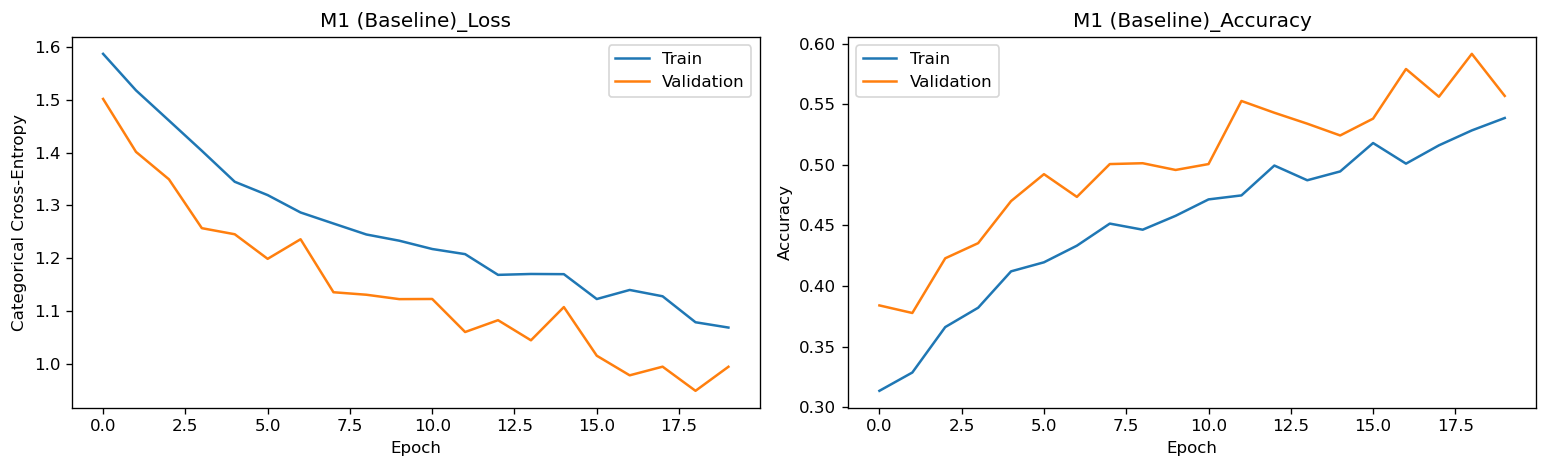


 M1 (Baseline): Classification Report
               precision    recall  f1-score   support

        crack       0.00      0.00      0.00        34
         dent       0.44      0.55      0.49       416
glass shatter       0.75      0.85      0.80       237
  lamp broken       0.50      0.52      0.51       176
      scratch       0.55      0.49      0.52       470
    tire flat       0.98      0.50      0.66       107

     accuracy                           0.56      1440
    macro avg       0.54      0.48      0.50      1440
 weighted avg       0.56      0.56      0.55      1440



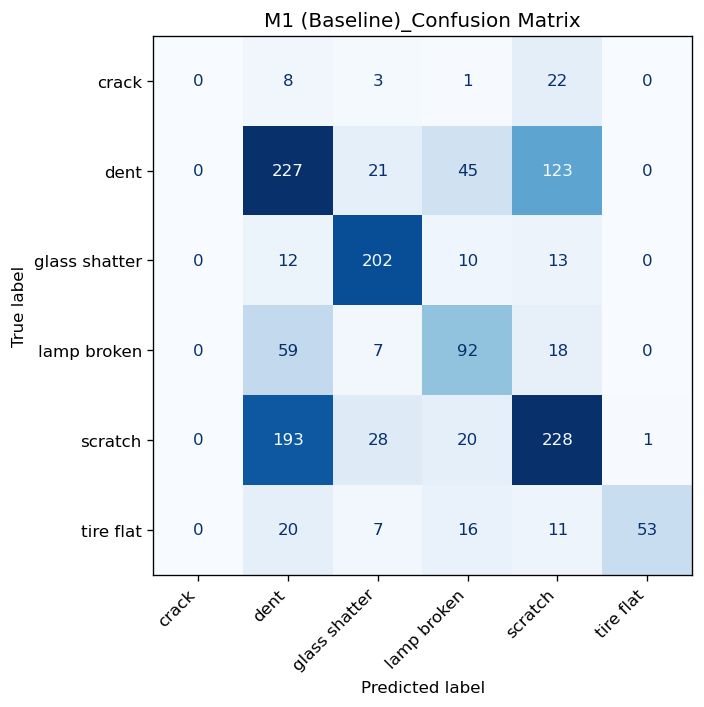

In [13]:
history_m1 = m1.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    verbose=1
)

plot_training_curves(history_m1, 'M1 (Baseline)')
report_m1 = evaluate_model(m1, val_gen, 'M1 (Baseline)', CLASS_LABELS)

In [22]:
# save the model

m1.save("models/model_1.h5")

### Model 2

Two changes from M1: the optimiser switches from SGD to Adam (which adapts per-parameter learning rates), and dropout is reduced from 0.5 to 0.3 to allow more neurons to participate during training. Early stopping stops training when validation loss stalls for 5 consecutive epochs.

In [14]:
train_gen, val_gen = make_generators(train_data, val_data, batch_size=32)

m2 = build_base_cnn(dropout_rate=0.3)
m2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.


Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 43s 235ms/step - accuracy: 0.3441 - loss: 1.5200 - val_accuracy: 0.3979 - val_loss: 1.3910
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 234ms/step - accuracy: 0.4477 - loss: 1.3104 - val_accuracy: 0.5250 - val_loss: 1.1596
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 233ms/step - accuracy: 0.4852 - loss: 1.2121 - val_accuracy: 0.5389 - val_loss: 1.0814
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.5113 - loss: 1.1625 - val_accuracy: 0.5354 - val_loss: 1.0570
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.5266 - loss: 1.1350 - val_accuracy: 0.5604 - val_loss: 1.0057
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 233ms/step - accuracy: 0.5398 - loss: 1.0884 - val_accuracy: 0.5285 - val_loss: 1.1320
Epoch 7/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 244ms/step - accuracy: 0.5531 - loss: 1.0575 - val_accuracy: 0.6000 - val_loss: 0.9405
Epoch 8/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.5556 - loss: 1

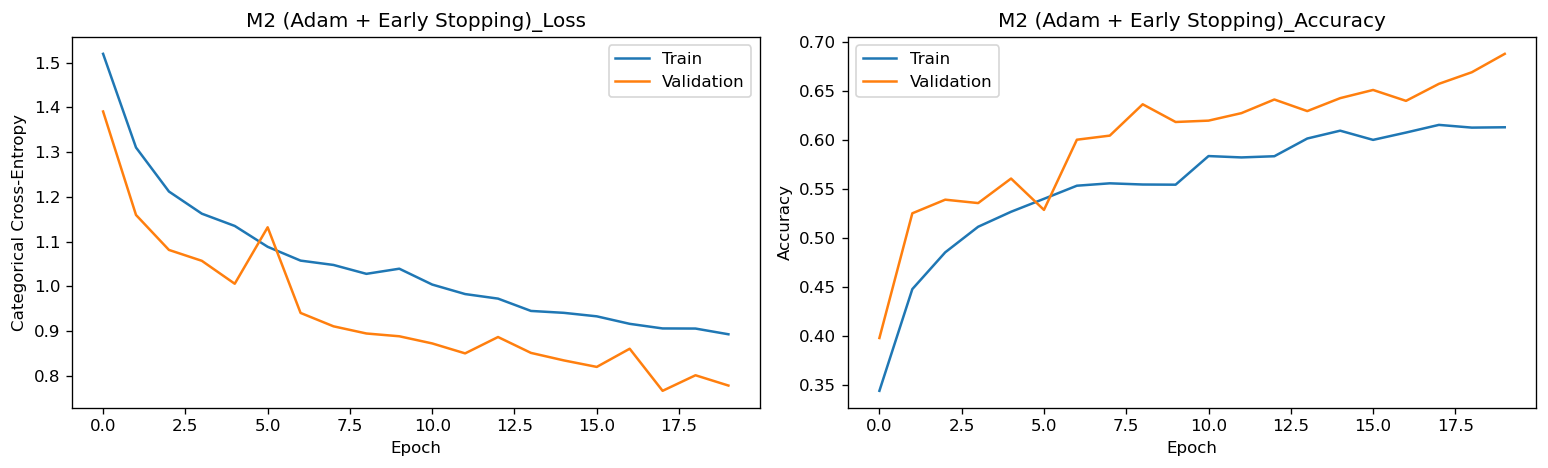


 M2 (Adam + Early Stopping): Classification Report
               precision    recall  f1-score   support

        crack       0.00      0.00      0.00        34
         dent       0.60      0.48      0.53       416
glass shatter       0.78      0.91      0.84       237
  lamp broken       0.65      0.60      0.62       176
      scratch       0.59      0.72      0.65       470
    tire flat       0.90      0.80      0.85       107

     accuracy                           0.66      1440
    macro avg       0.59      0.59      0.58      1440
 weighted avg       0.64      0.66      0.64      1440



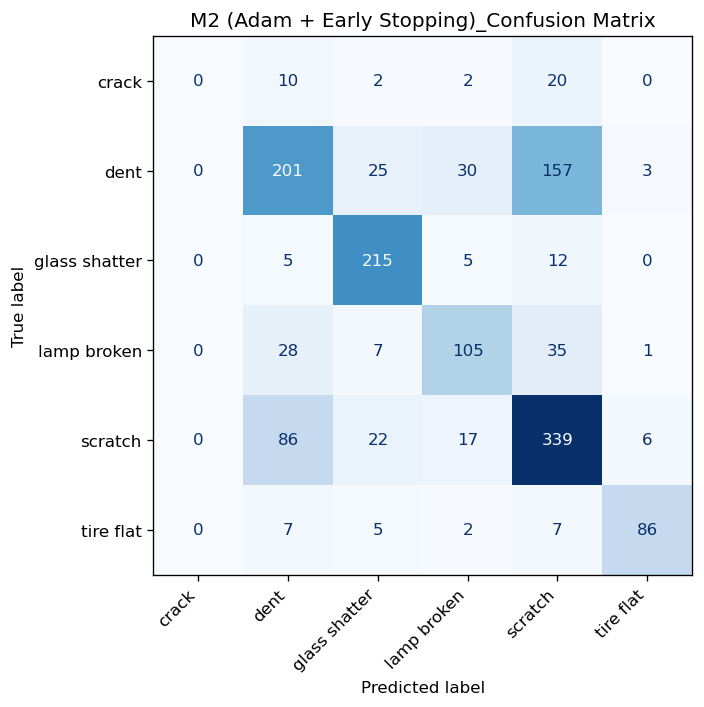

In [15]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_m2 = m2.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1)

print(f'Training stopped at epoch {len(history_m2.history["loss"])}')
plot_training_curves(history_m2, 'M2 (Adam + Early Stopping)')
report_m2 = evaluate_model(m2, val_gen, 'M2 (Adam + Early Stopping)', CLASS_LABELS)

In [23]:
# save the model

m2.save("models/model_2.h5")

### Model 3 

This model moves back to SGD but with a larger batch size (64 vs 32). Larger batches produce more stable gradient estimates, which can help SGD converge more smoothly. 


_This configuration produced the shortest training time of all four models._

In [16]:
# Rebuild generators with batch_size=64
train_gen_64, val_gen_64 = make_generators(train_data, val_data, batch_size=64)

m3 = build_base_cnn(dropout_rate=0.3)
m3.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.


Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 45s 493ms/step - accuracy: 0.3205 - loss: 1.5661 - val_accuracy: 0.3660 - val_loss: 1.4660
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 479ms/step - accuracy: 0.3837 - loss: 1.4457 - val_accuracy: 0.3861 - val_loss: 1.4166
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 481ms/step - accuracy: 0.4182 - loss: 1.3702 - val_accuracy: 0.4514 - val_loss: 1.2846
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 479ms/step - accuracy: 0.4425 - loss: 1.3261 - val_accuracy: 0.4701 - val_loss: 1.2166
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 481ms/step - accuracy: 0.4533 - loss: 1.2775 - val_accuracy: 0.4722 - val_loss: 1.2636
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 479ms/step - accuracy: 0.4563 - loss: 1.2622 - val_accuracy: 0.5125 - val_loss: 1.1436
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 479ms/step - accuracy: 0.4797 - loss: 1.1998 - val_accuracy: 0.5007 - val_loss: 1.1114
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 485ms/step - accuracy: 0.4884 - loss: 1.1882 - val_accu

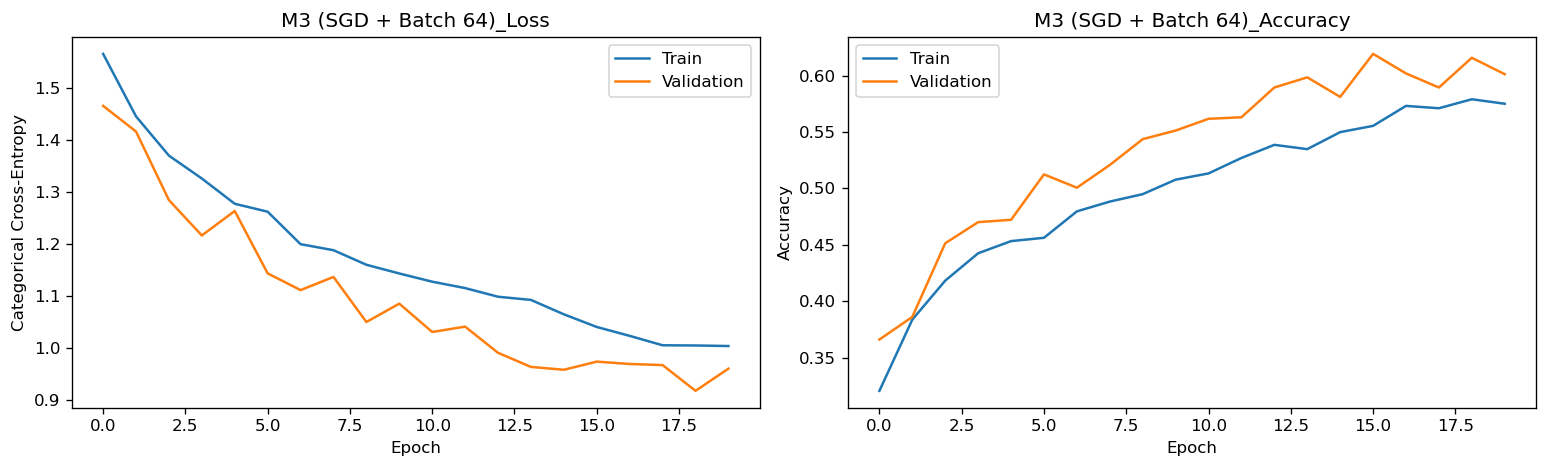


 M3 (SGD + Batch 64): Classification Report
               precision    recall  f1-score   support

        crack       0.00      0.00      0.00        34
         dent       0.54      0.50      0.52       416
glass shatter       0.68      0.89      0.77       237
  lamp broken       0.58      0.57      0.58       176
      scratch       0.59      0.61      0.60       470
    tire flat       0.91      0.74      0.81       107

     accuracy                           0.62      1440
    macro avg       0.55      0.55      0.55      1440
 weighted avg       0.60      0.62      0.60      1440



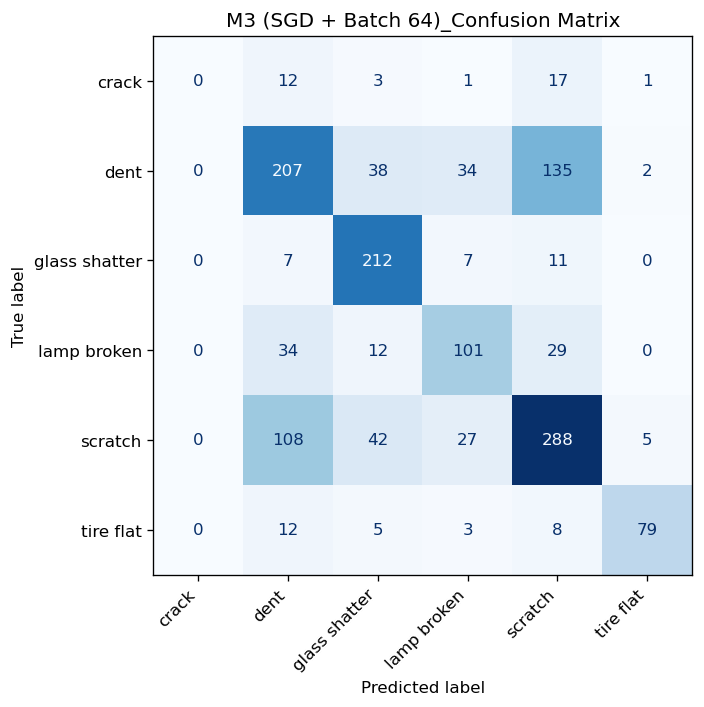

In [17]:
history_m3 = m3.fit(
    train_gen_64,
    epochs=20,
    validation_data=val_gen_64,
    callbacks=[early_stop],
    verbose=1)

print(f'Training stopped at epoch {len(history_m3.history["loss"])}')
plot_training_curves(history_m3, 'M3 (SGD + Batch 64)')
report_m3 = evaluate_model(m3, val_gen_64, 'M3 (SGD + Batch 64)', CLASS_LABELS)

In [24]:
# save the model

m3.save("models/model_3.h5")

### Model 4

Batch normalisation is added after each pooling layer. It normalises the activations within each mini-batch, which typically speeds up convergence and improves stability. 

_This was the only model where early stopping was applied before epoch 20._

In [18]:
train_gen, val_gen = make_generators(train_data, val_data, batch_size=32)

m4 = build_base_cnn(dropout_rate=0.3, batch_norm=True)
m4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Found 5760 validated image filenames belonging to 6 classes.
Found 1440 validated image filenames belonging to 6 classes.


Epoch 1/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 46s 249ms/step - accuracy: 0.3283 - loss: 1.9640 - val_accuracy: 0.1986 - val_loss: 3.3742
Epoch 2/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 45s 248ms/step - accuracy: 0.3457 - loss: 1.5974 - val_accuracy: 0.3458 - val_loss: 1.6684
Epoch 3/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 45s 248ms/step - accuracy: 0.3623 - loss: 1.5218 - val_accuracy: 0.3757 - val_loss: 1.4412
Epoch 4/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 245ms/step - accuracy: 0.3934 - loss: 1.4371 - val_accuracy: 0.4542 - val_loss: 1.3887
Epoch 5/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 45s 248ms/step - accuracy: 0.4215 - loss: 1.3629 - val_accuracy: 0.3917 - val_loss: 1.4958
Epoch 6/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 247ms/step - accuracy: 0.4203 - loss: 1.3306 - val_accuracy: 0.4437 - val_loss: 1.3499
Epoch 7/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 246ms/step - accuracy: 0.4274 - loss: 1.3129 - val_accuracy: 0.4153 - val_loss: 1.4031
Epoch 8/20
180/180 ━━━━━━━━━━━━━━━━━━━━ 44s 246ms/step - accuracy: 0.4321 - loss: 1

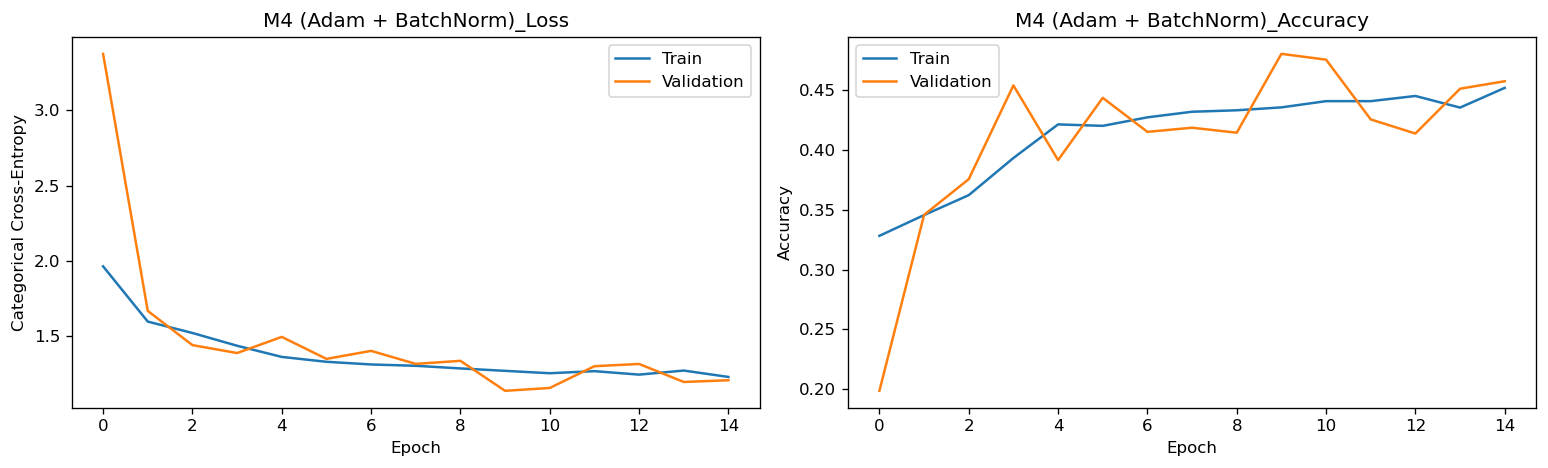


 M4 (Adam + BatchNorm): Classification Report
               precision    recall  f1-score   support

        crack       0.00      0.00      0.00        34
         dent       0.32      0.02      0.03       416
glass shatter       0.69      0.84      0.76       237
  lamp broken       0.00      0.00      0.00       176
      scratch       0.40      0.87      0.55       470
    tire flat       0.78      0.72      0.75       107

     accuracy                           0.48      1440
    macro avg       0.36      0.41      0.35      1440
 weighted avg       0.39      0.48      0.37      1440



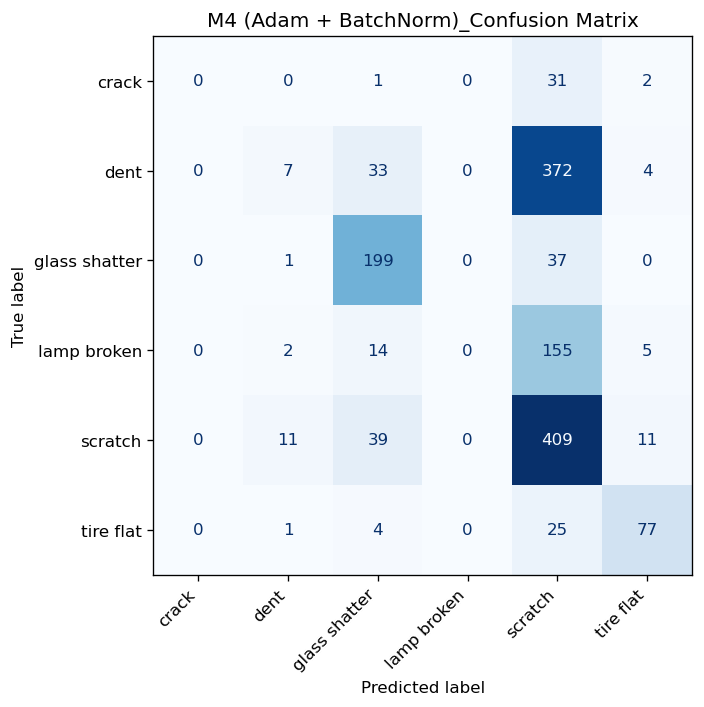

In [19]:
history_m4 = m4.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=[early_stop],
    verbose=1)

print(f'Training stopped at epoch {len(history_m4.history["loss"])}')
plot_training_curves(history_m4, 'M4 (Adam + BatchNorm)')
report_m4 = evaluate_model(m4, val_gen, 'M4 (Adam + BatchNorm)', CLASS_LABELS)

In [25]:
# save the model

m4.save("models/model_4.h5")

## Model Comparison & Conclusions

Each iteration modified one or more hyperparameters to study the effect on training stability and validation performance.

| Model | Optimiser | Batch Size | Dropout | Early Stopping | Batch Norm |
|---|---|---|---|---|---|
| M1 | SGD (lr=0.01, mom=0.9) | 32 | 0.5 | No | No |
| M2 | Adam (lr=0.001) | 32 | 0.3 | Yes (patience=5) | No |
| M3 | SGD (lr=0.01, mom=0.9) | 64 | 0.3 | Yes (patience=5) | No |
| M4 | Adam (lr=0.001) | 32 | 0.3 | Yes (patience=5) | Yes |


_lr = learning rate_
- Controls how large each weight update is during training.
- A higher learning rate can train faster but may overshoot the best solution, while a lower learning rate is more stable but slower.

_mom = momentum_
- Helps the optimiser keep moving in a consistent direction by carrying forward part of the previous update. This can speed up training and reduce noisy updates.

In [27]:
# Summary table, manually populated from the classification reports above
summary = pd.DataFrame([
    {'Model': 'M1',
     'Accuracy': 0.56, 'Macro F1': 0.50, 'Weighted F1': 0.55, 'Epochs': 20},
    {'Model': 'M2',
     'Accuracy': 0.66, 'Macro F1': 0.58, 'Weighted F1': 0.64, 'Epochs': 20},
    {'Model': 'M3',
     'Accuracy': 0.62, 'Macro F1': 0.55, 'Weighted F1': 0.60, 'Epochs': 20},
    {'Model': 'M4',
     'Accuracy': 0.48, 'Macro F1': 0.35, 'Weighted F1': 0.37, 'Epochs': 15},
])

summary.set_index('Model')

,Accuracy,Macro F1,Weighted F1,Epochs
Model,,,,
M1,0.56,0.50,0.55,20
M2,0.66,0.58,0.64,20
M3,0.62,0.55,0.60,20
M4,0.48,0.35,0.37,15


### Key Findings

- M2 achieved the highest overall performance, with an accuracy of 0.66, macro F1-score of 0.58 and weighted F1-score of 0.64. This indicates that the combination of Adam optimisation, dropout regularisation and early stopping produced the strongest results among the four tested models.

- The learning curves show that M1, M2 and M3 trained relatively smoothly, with decreasing loss and increasing accuracy across epochs. M4, which added Batch Normalisation, showed less stable validation behaviour and produced the weakest final performance, suggesting that this configuration did not improve generalisation on this dataset.

- Overall accuracy remained modest, ranging from approximately 48% to 66%. This is likely due to the difficulty of distinguishing visually similar categories such as cracks, scratches and dents, as well as the limitations of training a CNN from scratch on a relatively small image dataset.

- The confusion matrices show that the models struggled especially with the crack class, while glass shatter and tire flat were generally recognised more reliably. Future improvement would likely require transfer learning with a pretrained architecture such as ResNet, EfficientNet or MobileNet, combined with stronger data augmentation and class-balancing techniques.

_The End_